# Iris Flower Classification Using Machine Learning

## Internship Track: Data Science

### Objective

The objective of this project is to build a machine learning classification system
that identifies the species of an Iris flower from its physical measurements.

The Iris dataset contains four features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The model classifies flowers into three species:

- Setosa
- Versicolor
- Virginica

Two classification algorithms are trained and compared:

1. Logistic Regression
2. K-Nearest Neighbours (KNN)

The models are evaluated using accuracy, confusion matrix, precision, recall,
and F1-score.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Display and visualization settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Iris dataset
# The dataset is built into scikit-learn, so no external download is required.

iris = load_iris()

print("Iris dataset loaded successfully!")

Iris dataset loaded successfully!


In [3]:
# Display basic information about the dataset

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

print("\nDataset Shape:")
print(iris.data.shape)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']

Dataset Shape:
(150, 4)


In [4]:
# Convert the dataset into a pandas DataFrame

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["species"] = iris.target

# Convert numerical target values to species names
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## Dataset Overview

The Iris dataset contains 150 observations and four numerical input features.
The target variable represents one of three Iris species.

In [5]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 150
Number of columns: 5


In [6]:
# Check the data types of all columns

print("Data Types:")
print(df.dtypes)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


In [7]:
# Check for missing/null values

print("Null values in each column:")
print(df.isnull().sum())

Null values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


### Null Value Observation

The dataset contains no missing values. Therefore, no missing-value
imputation is required before training the machine learning models.

In [8]:
# Descriptive statistics

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Statistical Observation

The descriptive statistics show the central tendency and spread of the four
flower measurements. Petal length and petal width show noticeable differences
between species, suggesting that they may be highly useful for classification.

In [9]:
# Class distribution

print(df["species"].value_counts())

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


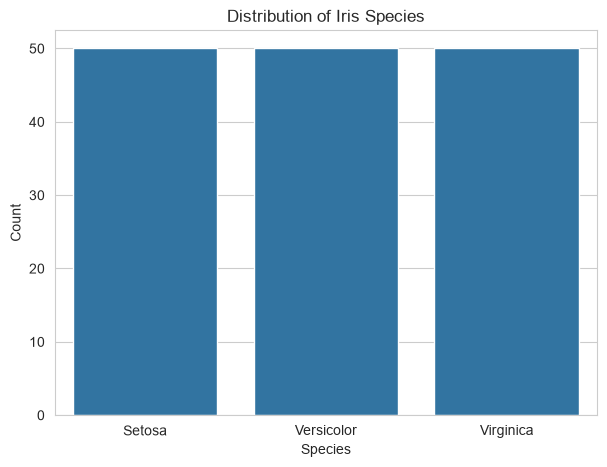

In [10]:
# Visualize the number of samples in each species

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

### Class Distribution Observation

Each Iris species has 50 observations. Therefore, the dataset is balanced,
which is useful for training and evaluating a classification model.

## Exploratory Data Analysis (EDA)

The following visualizations help identify relationships between features and
differences among the three Iris species.

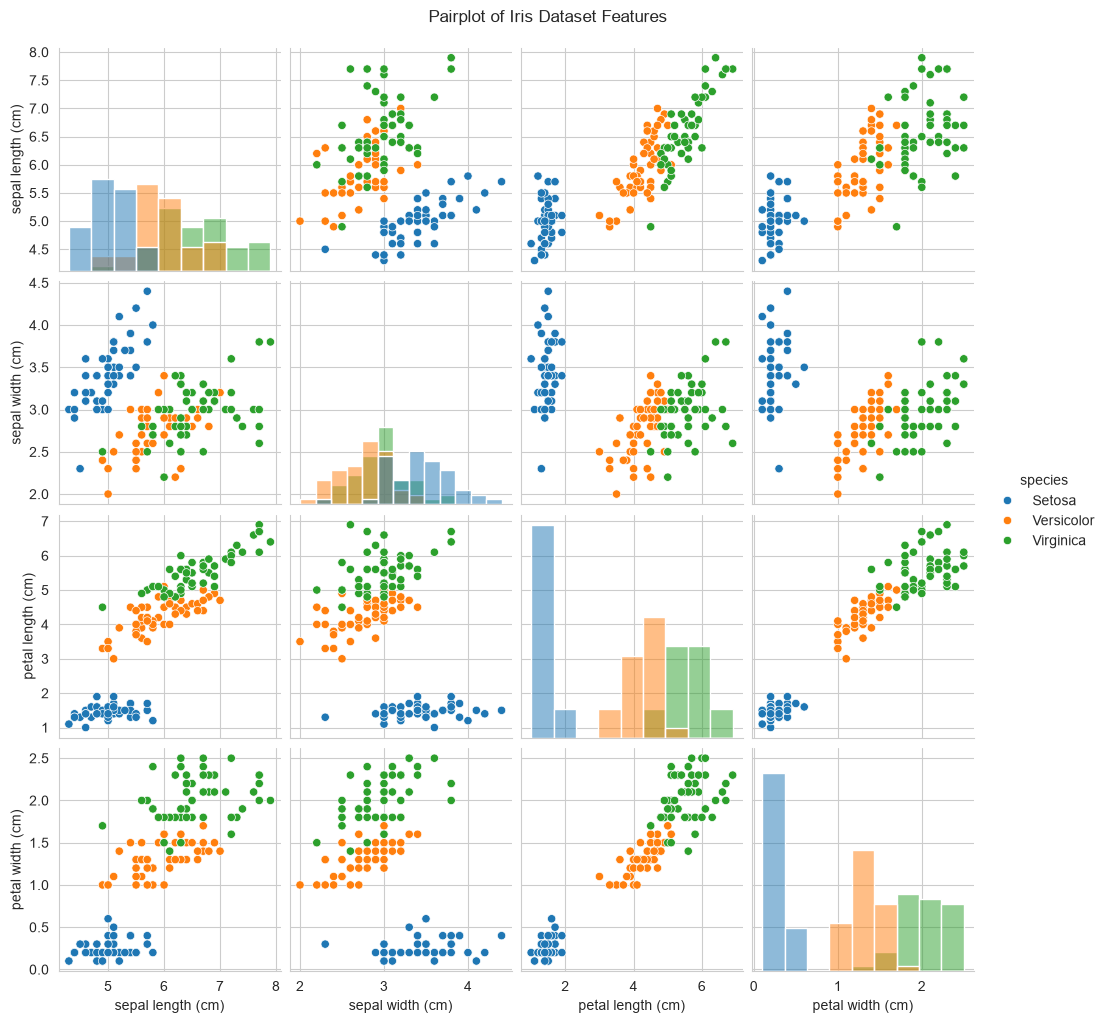

In [11]:
# Pairplot showing relationships between all numerical features

sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle("Pairplot of Iris Dataset Features", y=1.02)
plt.show()

### Pairplot Observation

The pairplot shows that Setosa is clearly separated from the other two species,
especially when using petal length and petal width.

Versicolor and Virginica have some overlap, but their petal measurements still
provide useful separation.

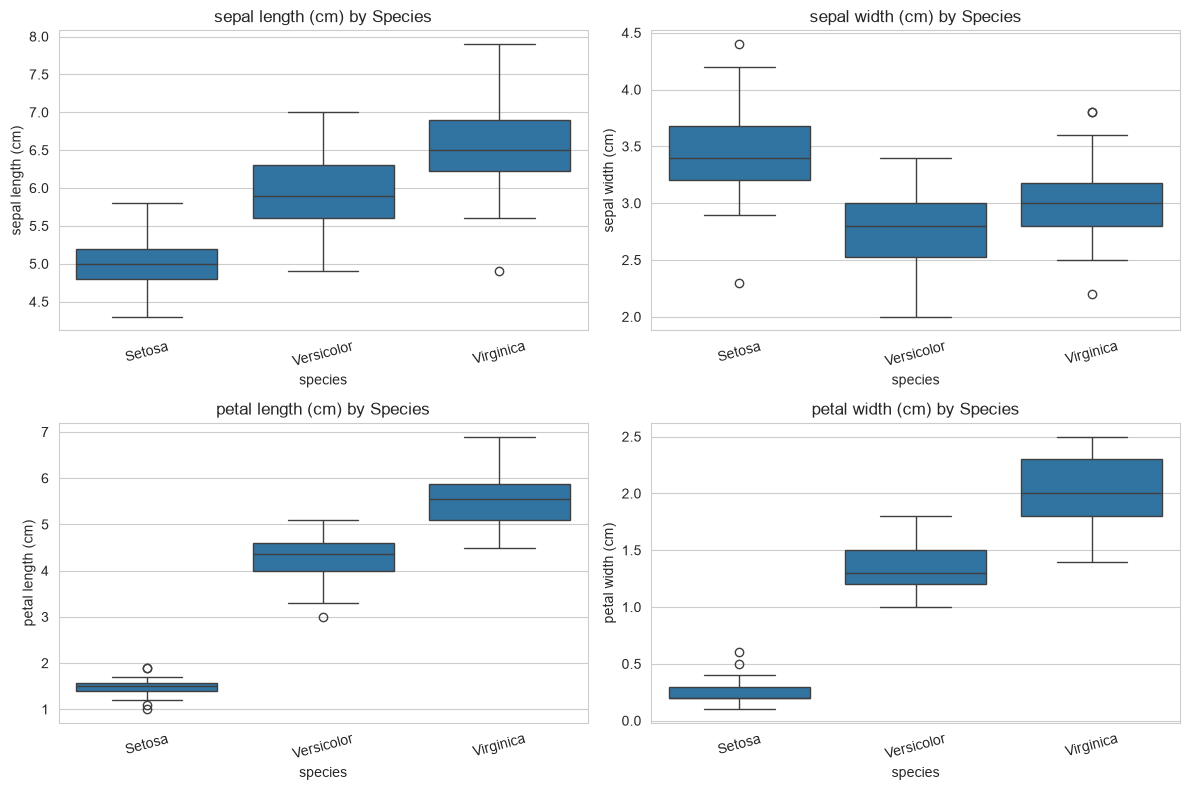

In [12]:
# Box plots for all four numerical features

features = iris.feature_names

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)

    sns.boxplot(
        data=df,
        x="species",
        y=feature
    )

    plt.title(f"{feature} by Species")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Box Plot Observation

The box plots show differences in feature distributions across the three
species.

Petal length and petal width show the strongest separation, while sepal
measurements show more overlap.

## Feature Selection Discussion

The Iris dataset contains four input features:

1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

Based on the pairplot and box plots, petal length and petal width appear to be
the most discriminative features.

Setosa has considerably smaller petal measurements than Versicolor and
Virginica. Versicolor and Virginica also show differences in their petal
measurements.

Although petal features appear to be the strongest predictors, all four
features are retained for model training because they provide useful
information and allow the classifiers to learn from the complete dataset.

In [13]:
# Define input features and target variable

X = df[iris.feature_names]
y = df["species"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


In [14]:
# Split the dataset into training and testing sets
# 80% is used for training and 20% for testing.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [15]:
# Standardize feature values
# Scaling is especially useful for KNN because it is distance-based.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


# Model 1 — Logistic Regression

In [16]:
# Create and train the Logistic Regression model

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [17]:
# Make predictions using Logistic Regression

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression predictions:")
print(y_pred_logistic)

Logistic Regression predictions:
['Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa' 'Versicolor'
 'Setosa' 'Setosa' 'Virginica' 'Versicolor' 'Virginica' 'Virginica'
 'Virginica' 'Versicolor' 'Setosa' 'Setosa' 'Setosa' 'Versicolor'
 'Versicolor' 'Virginica' 'Setosa' 'Virginica' 'Versicolor' 'Versicolor'
 'Virginica' 'Virginica' 'Versicolor' 'Setosa' 'Virginica' 'Setosa']


In [18]:
# Evaluate Logistic Regression accuracy

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")

Logistic Regression Accuracy: 0.9333


In [19]:
# Classification report for Logistic Regression

print("Logistic Regression Classification Report:\n")
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



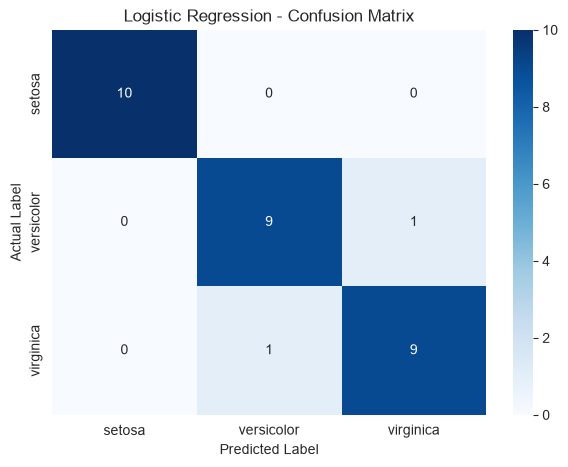

In [20]:
# Confusion matrix for Logistic Regression

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Logistic Regression Evaluation

The confusion matrix shows the number of correctly and incorrectly classified
test samples for each Iris species. Precision, recall, and F1-score provide
additional information about classification performance.

# Model 2 — K-Nearest Neighbours (KNN)

In [21]:
# Create and train the KNN classifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(
    X_train_scaled,
    y_train
)

print("KNN model trained successfully!")

KNN model trained successfully!


In [22]:
# Make predictions using KNN

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN predictions:")
print(y_pred_knn)

KNN predictions:
['Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa' 'Versicolor'
 'Setosa' 'Setosa' 'Virginica' 'Versicolor' 'Virginica' 'Virginica'
 'Virginica' 'Versicolor' 'Setosa' 'Setosa' 'Setosa' 'Versicolor'
 'Versicolor' 'Versicolor' 'Setosa' 'Virginica' 'Versicolor' 'Versicolor'
 'Virginica' 'Versicolor' 'Versicolor' 'Setosa' 'Virginica' 'Setosa']


In [23]:
# Evaluate KNN accuracy

knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN Accuracy: 0.9333


In [24]:
# Classification report for KNN

print("KNN Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

KNN Classification Report:

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.83      1.00      0.91        10
   Virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



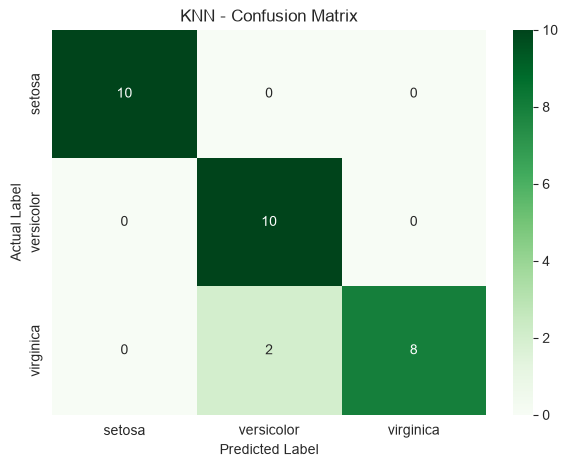

In [25]:
# Confusion matrix for KNN

cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Model Comparison

In [26]:
# Compare the accuracy of both models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbours"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.933333


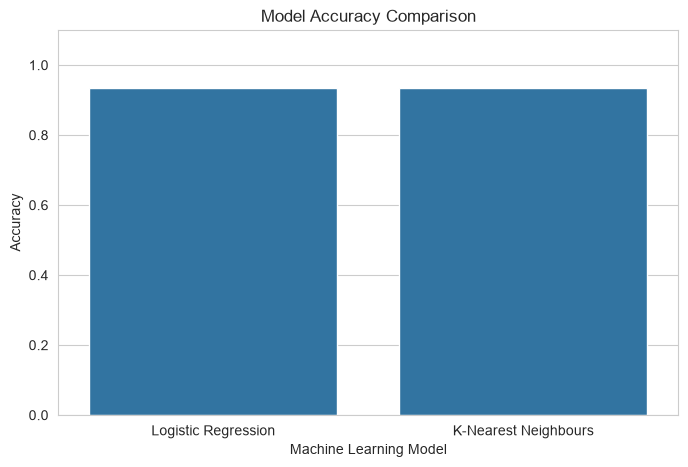

In [27]:
# Visualize model accuracy comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)

plt.show()

In [28]:
# Identify the best-performing model

if logistic_accuracy >= knn_accuracy:
    best_model = "Logistic Regression"
    best_accuracy = logistic_accuracy
else:
    best_model = "K-Nearest Neighbours"
    best_accuracy = knn_accuracy

print("Best Performing Model:", best_model)
print(f"Best Accuracy: {best_accuracy:.4f}")

Best Performing Model: Logistic Regression
Best Accuracy: 0.9333


## Best Model Justification

The model with the highest test accuracy is selected as the best-performing
model. Accuracy is used as the primary comparison metric because the Iris
dataset is balanced across its three classes.

The classification report and confusion matrix are also considered to verify
that the selected model performs well across all three species rather than
relying only on a single accuracy value.

# Final Observations

1. The Iris dataset contains 150 observations and four numerical features.

2. The dataset contains three species: Setosa, Versicolor, and Virginica,
   with 50 observations for each species.

3. No missing values were found.

4. Exploratory analysis showed that petal length and petal width are the most
   discriminative features.

5. Two classification algorithms were trained:
   - Logistic Regression
   - K-Nearest Neighbours

6. Both models achieved strong classification performance.

7. Confusion matrices and classification reports were used to examine the
   detailed performance of each classifier.

8. The model with the highest test accuracy was selected as the best model.

# Conclusion

In this project, a machine learning classification system was developed to
identify Iris flower species from their physical measurements.

The complete machine learning workflow was followed, including data loading,
data inspection, exploratory data analysis, visualization, feature analysis,
train/test splitting, feature scaling, model training, evaluation, comparison,
and model selection.

The analysis showed that petal length and petal width are particularly useful
for distinguishing the three Iris species.

Logistic Regression and K-Nearest Neighbours were trained and evaluated using
accuracy, precision, recall, F1-score, and confusion matrices.

The classifier with the highest test accuracy was selected as the
best-performing model.

# Internship Task Completion Checklist

| Requirement | Status |
|---|---|
| Load Iris dataset | ✅ Completed |
| EDA - Shape | ✅ Completed |
| EDA - Data types | ✅ Completed |
| EDA - Null value check | ✅ Completed |
| Descriptive statistics | ✅ Completed |
| Pairplot | ✅ Completed |
| Box plots | ✅ Completed |
| Feature selection discussion | ✅ Completed |
| Train/test split | ✅ Completed |
| Logistic Regression | ✅ Completed |
| K-Nearest Neighbours | ✅ Completed |
| Accuracy evaluation | ✅ Completed |
| Confusion matrix | ✅ Completed |
| Classification report | ✅ Completed |
| Model comparison | ✅ Completed |
| Best model identification | ✅ Completed |
| Clean commented notebook | ✅ Completed |